<a href="https://colab.research.google.com/github/ochilovu2010/IOAI/blob/main/IOAI_2026/Double_Agent_Dillamma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IOAI-official/IOAI-2026/blob/main/Individual-Contest/4_Double_Agent_Dilemma/code/baseline/solution.ipynb)

# Double Agent Dilemma — baseline on Google Colab

Run all (GPU runtime recommended). The first cell fetches the [dataset](https://huggingface.co/datasets/IOAI-official/ioai-2026-double-agent-dilemma) and recreates the contest file layout; every cell after it is the original baseline, with the two frozen models loaded directly from torchvision and the Hugging Face hub.

> **Unofficial educational version** — provided so the task can be used outside the contest environment, reading the data directly from the Hugging Face dataset. The official contest artifacts are preserved in `code/baseline-original/` and `code/grading-original/`.

In [1]:
# ============================ Colab setup (added) ============================
# Downloads the task dataset from Hugging Face and lays it out exactly as the
# contest environment did. Everything below this cell is the original baseline.
import os, sys, shutil, subprocess
from pathlib import Path
def sh(c): print('+',c); subprocess.run(c, shell=True, check=True)
sh('pip -q install timm safetensors huggingface_hub')

from huggingface_hub import snapshot_download
DATA = Path(snapshot_download("IOAI-official/ioai-2026-double-agent-dilemma", repo_type="dataset"))
def link(src, dst):
    dst = Path(dst); dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.is_symlink() or dst.exists(): return
    os.symlink(src, dst)
# merged dataset root: split folders + *_answers files, public and private together
DSROOT = Path("/content/dsroot").resolve()
for sub in ("public","private"):
    d = DATA/sub
    if d.is_dir():
        for child in d.iterdir():
            link(child, DSROOT/child.name)
print("dataset root:", DSROOT, "->", sorted(p.name for p in DSROOT.iterdir()))

ws = Path.cwd()
for name in ("train","test_public","pretrain","pretest"): link(DSROOT/name, ws/"dataset"/name)

print("models load directly from torchvision / HF hub at the model cell")


+ pip -q install timm safetensors huggingface_hub


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 427 files:   0%|          | 0/427 [00:00<?, ?it/s]

dataset root: /content/dsroot -> ['pretest', 'pretrain', 'test_leaderboard_a', 'test_leaderboard_b', 'test_public', 'train']
models load directly from torchvision / HF hub at the model cell


# Double Agent Dilemma — Baseline

## 1. Setup

You load the two pretrained models (ResNet18 and ViT-Tiny) below and, for every image,
produce two perturbation tensors. Scoring is run by the graders after you submit — your
only job is to build the perturbation files.


In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from tqdm.auto import tqdm
import os


### PLEASE DO NOT CHANGE THESE VARIABLES ###
TRAIN_SPLIT = os.environ.get("TRAIN_SPLIT", "train")
TEST_SPLIT = os.environ.get("TEST_SPLIT", "test_public")
MODELS_ROOT = Path(os.environ.get("MODELS_DIR", "models"))
DATASET_ROOT = Path(os.environ.get("DATA_DIR", "dataset"))

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Load the data

Two splits are provided:

- `train` (100 images) — explore and tune here.
- `test_public.` (100 images) — evaluation and debugging.

For labels.json, each item is `{'idx': int, 'image_path': Path, 'label': int}`, where `label` is the true
ImageNet-1K class index (0–999). Images have **varying original resolutions**.

In [3]:
import json

def load_split(split: str):
    """Load a dataset split (e.g. 'train', 'test_public.').

    Reads from dataset/<split>/ if present, otherwise extracts dataset/<split>.tar.gz.
    """
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        raise FileNotFoundError(
            f"Dataset split '{split}' not found in {DATASET_ROOT}. "
            "Please make sure to extract the dataset first."
        )

    labels_path = split_dir / "labels.json"
    if not labels_path.exists():
        raise FileNotFoundError(
            f"labels.json not found in {split_dir}."
        )

    with open(labels_path) as f:
        labels = json.load(f)

    images_dir = split_dir / "images"
    items = []
    for idx_str, label in sorted(labels.items(), key=lambda x: int(x[0])):
        idx = int(idx_str)
        image_path = images_dir / f"{idx:04d}.png"
        items.append({"idx": idx, "image_path": image_path, "label": label})

    return items

In [4]:
train_data = load_split(TRAIN_SPLIT)
test_data = load_split(TEST_SPLIT)

print(f"train : {len(train_data)} images")
print(f"test  : {len(test_data)} images")

sample = train_data[0]
img0 = Image.open(sample["image_path"]).convert("RGB")
print(f"\nExample item: idx={sample['idx']}  label={sample['label']}  size={img0.size} (W×H)")

train : 100 images
test  : 100 images

Example item: idx=0  label=160  size=(495, 500) (W×H)


## 3. The Image Processing

The evaluation transform is fixed and applied to `image + perturbation` (pixels clipped to
`[0, 1]`) before either model sees it:

```
Resize(256) → CenterCrop(224) → Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
```

Below we load both models and the exact preprocessing, then confirm both classify the clean
image correctly — the starting point every attack must break for exactly one model at a time.


In [5]:
import timm
import torch
from torchvision import models

resnet = models.resnet18(pretrained=True).to(DEVICE).eval()

vit = timm.create_model("vit_tiny_patch16_224", pretrained=True).to(DEVICE).eval()

for p in list(resnet.parameters()) + list(vit.parameters()):
    p.requires_grad = False

_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(3, 1, 1)

def preprocess(img_tensor):
    """Raw [0,1] CxHxW tensor -> normalized 3x224x224 (matches the grader transform)."""
    img = TF.resize(img_tensor, size=256, interpolation=T.InterpolationMode.BILINEAR)
    img = TF.center_crop(img, output_size=224)
    return (img - _MEAN) / _STD

@torch.no_grad()
def predict(img_tensor):
    inp = preprocess(img_tensor).unsqueeze(0)
    return int(resnet(inp).argmax(1)), int(vit(inp).argmax(1))

img_t = TF.to_tensor(img0).to(DEVICE)
r_pred, v_pred = predict(img_t)
print(f"True label     : {sample['label']}")
print(f"ResNet18 (Rex) : {r_pred}  {'✓' if r_pred == sample['label'] else '✗'}")
print(f"ViT-Tiny (Vita): {v_pred}  {'✓' if v_pred == sample['label'] else '✗'}")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 89.6MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

True label     : 160
ResNet18 (Rex) : 160  ✓
ViT-Tiny (Vita): 160  ✓


## 4. How you are scored


```
Pure Score = (Score_A + Score_B) / (2M)
```

Then the L2 size of your perturbations is folded in as a multiplicative **penalty factor**
`PF` — the smaller (fainter) your perturbations, the higher `PF` (up to a neutral `1.0`);
larger, more visible perturbations are penalised (down to `0.5`). The final score is

```
S_final = Pure Score × PF
```

Scoring is performed by the graders on the hidden evaluator; you only produce `preds`. The
goal is to maximise Success A and B **while keeping each perturbation as small as possible.**


## 5. The baseline: naive constant noise

This baseline is intentionally the simplest thing that runs the full workflow — it is a
**floor**, not a real attack. For every image it produces one tiny, uniform perturbation and
uses it for *both* Type A and Type B:

```
δ = mean_pixel_value × EPSILON        (EPSILON = 1e-4)
```

That is a barely-there constant offset added to every pixel. It does not target either model,
so it fools essentially no one — expect a **near-zero pure score**. What it *does* do is
exercise every moving part end to end: load an image, build `(δ_a, δ_b)` at the original
resolution, and package a submission zip. Your job is to
replace `_generate_naive_noise` with something that actually splits the two inspectors.

The `Solution` class matches the interface the pipeline expects: `run(data)` returns
`(preds, targets)`, where `preds` is a list of `(delta_a, delta_b)` **CPU** tensors, one per
image, each shaped like the raw image (`3 × H × W`).

# Solution of the problem

In [6]:
import os
import json
import torch
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset


train_dir = "/content/dataset/train/images"
images = {}
with open("/content/dataset/train/labels.json") as f:
  data = json.load(f)
for i in os.listdir(train_dir):
  images[os.path.join(train_dir, i)] = data[str(int(i[:4]))]


(439, 439)


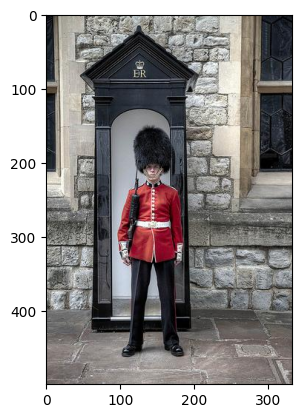

In [32]:
img_tensor = T.functional.to_tensor(Image.open('/content/dataset/train/images/0001.png')).to(DEVICE)
processed = preprocess(img_tensor)
plt.imshow(img_tensor.permute(1, 2, 0).cpu())
print(predict(img_tensor))


device = 'cuda' if torch.cuda.is_available() else 'cpu'

from torch import nn

criterion = nn.CrossEntropyLoss()

def first(image):
  answer = vit(image).argmax(1)
  print(answer)
  image = image.to(device)
  delta = nn.Parameter(torch.zeros_like(image))
  optimizer = torch.optim.AdamW([delta], lr = 0.01)
  for step in range(100):
    optimizer.zero_grad()
    testimage = image+delta
    resnetprobabilities = resnet(testimage)
    vitprobabilities = vit(testimage)
    loss_resnet = F.cross_entropy(resnetprobabilities, answer)
    loss_vit = F.cross_entropy(vitprobabilities, answer)
    loss = loss_resnet - loss_vit
    print(loss)
    loss.backward()
    optimizer.step()
  return delta.detach()+image

def first(image):
  answer = vit(image).argmax(1)
  print(answer)
  image = image.to(device)
  delta = nn.Parameter(torch.zeros_like(image))
  optimizer = torch.optim.AdamW([delta], lr = 0.01)
  for step in range(100):
    optimizer.zero_grad()
    testimage = image+delta
    resnetprobabilities = resnet(testimage)
    vitprobabilities = vit(testimage)
    loss_resnet = F.cross_entropy(resnetprobabilities, answer)
    loss_vit = F.cross_entropy(vitprobabilities, answer)
    loss = loss_resnet - loss_vit
    loss.backward()
    optimizer.step()
  return delta.detach()+image

def second(image):
  answer = vit(image).argmax(1)
  print(answer)
  image = image.to(device)
  delta = nn.Parameter(torch.zeros_like(image))
  optimizer = torch.optim.AdamW([delta], lr = 0.01)
  for step in range(100):
    optimizer.zero_grad()
    testimage = image+delta
    resnetprobabilities = resnet(testimage)
    vitprobabilities = vit(testimage)
    loss_resnet = F.cross_entropy(resnetprobabilities, answer)
    loss_vit = F.cross_entropy(vitprobabilities, answer)
    loss = loss_vit - loss_resnet
    loss.backward()
    optimizer.step()
  return delta.detach()+image


In [33]:
answer = first(processed.unsqueeze(0))
secondanswer = second(processed.unsqueeze(0))
print(resnet(answer).argmax(1), vit(answer).argmax(1))
print(resnet(secondanswer).argmax(1), vit(secondanswer).argmax(1))

tensor([439], device='cuda:0')
tensor([439], device='cuda:0')
tensor([439], device='cuda:0') tensor([743], device='cuda:0')
tensor([614], device='cuda:0') tensor([439], device='cuda:0')


In [47]:

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensures deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

EPSILON = 0.0001


class Solution:
    def __init__(self):
        # We assume resnet, vit, preprocess, and device are already defined globally
        pass

    def first(self, image, answer):
        """Type A: Fool ViT, ResNet correct."""
        image = image.to(device)
        answer = answer.to(device)
        delta = nn.Parameter(torch.zeros_like(image))
        optimizer = torch.optim.AdamW([delta], lr=0.001)

        for step in range(10000):
            optimizer.zero_grad()

            testimage = torch.clamp(image + delta, 0.0, 1.0)

            model_input = preprocess(testimage)

            resnetprobabilities = resnet(model_input)
            vitprobabilities = vit(model_input)

            pred_resnet = resnetprobabilities.argmax(1)
            pred_vit = vitprobabilities.argmax(1)
            if pred_resnet == answer and pred_vit != answer:
                break

            loss_resnet = F.cross_entropy(resnetprobabilities, answer)
            loss_vit = F.cross_entropy(vitprobabilities, answer)

            loss = loss_resnet - loss_vit
            loss.backward()
            optimizer.step()

        return delta.detach().cpu()

    def second(self, image, answer):
        """Type B: Fool ResNet, ViT correct."""
        image = image.to(device)
        answer = answer.to(device)
        delta = nn.Parameter(torch.zeros_like(image))
        optimizer = torch.optim.AdamW([delta], lr=0.001)

        for step in range(10000):
            optimizer.zero_grad()

            testimage = torch.clamp(image + delta, 0.0, 1.0)
            model_input = preprocess(testimage)

            resnetprobabilities = resnet(model_input)
            vitprobabilities = vit(model_input)

            pred_resnet = resnetprobabilities.argmax(1)
            pred_vit = vitprobabilities.argmax(1)
            if pred_vit == answer and pred_resnet != answer:
                break

            loss_resnet = F.cross_entropy(resnetprobabilities, answer)
            loss_vit = F.cross_entropy(vitprobabilities, answer)

            loss = loss_vit - loss_resnet
            loss.backward()
            optimizer.step()

        return delta.detach().cpu()

    def run(self, data):
        """
        Return (preds, targets).
        preds:   list of (delta_a, delta_b) tensors
        targets: data (list of {'idx', 'image_path', 'label'})
        """
        preds = []

        resnet.eval()
        vit.eval()
        for param in resnet.parameters(): param.requires_grad = False
        for param in vit.parameters(): param.requires_grad = False

        for item in tqdm(data, desc="Generating targeted perturbations"):
            img = Image.open(item["image_path"]).convert("RGB")

            img_tensor = T.functional.to_tensor(img).unsqueeze(0)

            label = torch.tensor([item["label"]])

            delta_a = self.first(img_tensor, label)
            delta_b = self.second(img_tensor, label)

            preds.append((delta_a.squeeze(0), delta_b.squeeze(0)))

        return preds, data

## 6. Run

We first try a small slice of the `train` split to see the workflow end-to-end, then run the
full `test` split below.


In [48]:
solver = Solution()

# Quick smoke test on a handful of images.
subset = train_data[:20]
preds, targets = solver.run(subset)

Generating targeted perturbations: 100%|██████████| 20/20 [00:06<00:00,  2.91it/s]


Then run on the full `test` split to generate a perturbation for every image.


In [49]:
test_preds, test_targets = solver.run(test_data)

Generating targeted perturbations: 100%|██████████| 100/100 [00:20<00:00,  4.94it/s]


## 7. Check the submission

Before zipping, sanity-check that the perturbation files are well-formed. `check()`
compares a directory of `.pt` files against the original images and verifies:

1. **Count** — one `_a.pt` and one `_b.pt` per image, and no stray non-`.pt` files.
2. **Naming** — indices `{idx}_a.pt` / `{idx}_b.pt` exactly cover the image indices.
3. **Loadable** — every `.pt` loads with `weights_only=True` and is a tensor.
4. **Shape** — each tensor matches its raw image's `(3, H, W)`.

It returns `(ok, report)`. Point it at a folder of `.pt` files and the split's
`images/` directory, e.g. `check("submission_pt/", "dataset/<split>/images/")`.


In [50]:
import os
from pathlib import Path
from PIL import Image
import torch


def check(submission_dir, images_dir):
    """Check perturbation files against original images.

    Parameters
    ----------
    submission_dir : str or Path
        Directory containing flat-listed .pt files named {idx}_a.pt and {idx}_b.pt.
    images_dir : str or Path
        Directory containing original .png images named {idx:04d}.png.

    Returns
    -------
    ok : bool
    report : str
    """
    sub = Path(submission_dir)
    img = Path(images_dir)
    ok_parts = []
    issues = []

    if not sub.is_dir():
        return False, f"ERROR: {sub} is not a directory."
    if not img.is_dir():
        return False, f"ERROR: {img} is not a directory."

    # -- Get expected indices from image files --
    png_files = sorted(img.glob("*.png"))
    if not png_files:
        return False, f"ERROR: No .png files found in {img}"

    expected_indices = []
    for pth in png_files:
        try:
            expected_indices.append(int(pth.stem))
        except ValueError:
            issues.append(f"Bad image filename: {pth.name}")

    n = len(expected_indices)
    ok_parts.append(f"Images found: {n} ({img})")

    # -- Check 1: Count --
    a_files = sorted(sub.glob("*_a.pt"))
    b_files = sorted(sub.glob("*_b.pt"))
    other = [f for f in sub.iterdir()
             if not f.name.endswith("_a.pt") and not f.name.endswith("_b.pt")]

    if other:
        issues.append(f"Non-.pt files ({len(other)}): {[f.name for f in other[:10]]}")
    else:
        ok_parts.append("All files are .pt")

    if len(a_files) != n:
        issues.append(f"Type A: {len(a_files)} files, expected {n}")
    else:
        ok_parts.append(f"Type A: {len(a_files)} files OK")

    if len(b_files) != n:
        issues.append(f"Type B: {len(b_files)} files, expected {n}")
    else:
        ok_parts.append(f"Type B: {len(b_files)} files OK")

    # -- Check 2: Naming --
    a_indices = set()
    for f in a_files:
        try:
            a_indices.add(int(f.stem.replace("_a", "")))
        except ValueError:
            issues.append(f"Bad filename: {f.name}")

    b_indices = set()
    for f in b_files:
        try:
            b_indices.add(int(f.stem.replace("_b", "")))
        except ValueError:
            issues.append(f"Bad filename: {f.name}")

    expected = set(expected_indices)
    if a_indices != expected:
        mi = sorted(expected - a_indices)[:10]
        ex = sorted(a_indices - expected)[:10]
        if mi: issues.append(f"Type A missing indices: {mi}")
        if ex: issues.append(f"Type A extra indices: {ex}")
    else:
        ok_parts.append("Type A indices: complete")

    if b_indices != expected:
        mi = sorted(expected - b_indices)[:10]
        ex = sorted(b_indices - expected)[:10]
        if mi: issues.append(f"Type B missing indices: {mi}")
        if ex: issues.append(f"Type B extra indices: {ex}")
    else:
        ok_parts.append("Type B indices: complete")

    # -- Check 3: Loadable .pt --
    load_fails = []
    for f in a_files + b_files:
        try:
            t = torch.load(f, weights_only=True)
            if not isinstance(t, torch.Tensor):
                load_fails.append(f"{f.name}: not a tensor ({type(t).__name__})")
        except Exception as e:
            load_fails.append(f"{f.name}: load error - {e}")

    if load_fails:
        issues.append(f"Load errors ({len(load_fails)}):")
        issues.extend(f"  {x}" for x in load_fails[:10])
    else:
        ok_parts.append(f"Load check: all {len(a_files)+len(b_files)} .pt files OK")

    # -- Check 4: Shape match --
    shape_issues = []
    shape_ok = 0

    for idx in sorted(expected_indices):
        img_path = img / f"{idx:04d}.png"
        if not img_path.exists():
            continue

        try:
            with Image.open(img_path) as pil_img:
                w, h = pil_img.size
                expected_shape = (3, h, w)
        except Exception as e:
            issues.append(f"Cannot read {img_path}: {e}")
            continue

        for tag, suffix in [("a", f"{idx}_a.pt"), ("b", f"{idx}_b.pt")]:
            fpath = sub / suffix
            if not fpath.exists():
                continue
            try:
                t = torch.load(fpath, weights_only=True)
                actual = tuple(t.shape)
                if actual != expected_shape:
                    shape_issues.append(f"{suffix}: got {actual}, expected {expected_shape}")
                else:
                    shape_ok += 1
            except Exception:
                pass

    if shape_issues:
        issues.append(f"Shape mismatches ({len(shape_issues)}):")
        issues.extend(f"  {x}" for x in shape_issues[:20])
        if len(shape_issues) > 20:
            issues.append(f"  ... and {len(shape_issues)-20} more")
    else:
        ok_parts.append(f"Shape match: all {shape_ok} tensors OK")

    # -- Report --
    ok = len(issues) == 0
    lines = []
    lines.append("=" * 60)
    lines.append(f"Submission: {sub}")
    lines.append(f"Images:     {img}")
    lines.append("=" * 60)

    if ok_parts:
        lines.append("\n[PASS]")
        for pt in ok_parts:
            lines.append(f"  + {pt}")

    if issues:
        lines.append(f"\n[FAIL] {len(issues)} issue(s):")
        for i, issue in enumerate(issues, 1):
            lines.append(f"  {i}. {issue}")
    else:
        lines.append("\n[RESULT] ALL CHECKS PASSED - Submission is valid!")

    lines.append("=" * 60)
    return ok, "\n".join(lines)


In [51]:
import tempfile
from pathlib import Path

# Materialize the perturbations to a temp folder and run the checks against the
# test split's images (this is the folder layout `check` expects).
_pt_dir = Path(tempfile.mkdtemp())
for (delta_a, delta_b), item in zip(test_preds, test_targets):
    idx = item["idx"]
    torch.save(delta_a.contiguous(), _pt_dir / f"{idx}_a.pt")
    torch.save(delta_b.contiguous(), _pt_dir / f"{idx}_b.pt")

_images_dir = DATASET_ROOT / TEST_SPLIT / "images"
ok, report = check(_pt_dir, _images_dir)
print(report)
assert ok, "Submission checks failed — fix the issues above before building the zip."


Submission: /tmp/tmpe56ruq8x
Images:     dataset/test_public/images

[PASS]
  + Images found: 100 (dataset/test_public/images)
  + All files are .pt
  + Type A: 100 files OK
  + Type B: 100 files OK
  + Type A indices: complete
  + Type B indices: complete
  + Load check: all 200 .pt files OK
  + Shape match: all 200 tensors OK

[RESULT] ALL CHECKS PASSED - Submission is valid!


## 8. Evaluate locally

Before packaging, run the official scoring formula locally using the
already-loaded models. This is the same logic the grader uses — it verifies
each perturbation against both models and computes:

```
Pure  = (Score_A + Score_B) / (2M)
PF    = 1.5 - 1/(1 + exp(-100000 * mean_norm))
Final = Pure * PF
```

Run this on both `train` and `test_public` to check your scores before submitting.

In [52]:
import math
from scipy.special import expit

K = 100_000

def compute_score(preds, targets, verbose=True):
    """Official scorer — mirrors evaluate.py exactly."""
    score_a = score_b = 0
    l2_list = []
    total = len(targets)

    with torch.no_grad():
        for (delta_a, delta_b), item in zip(preds, targets):
            img = Image.open(item["image_path"]).convert("RGB")
            img_t = TF.to_tensor(img).to(DEVICE)
            label = item["label"]

            da = delta_a.to(DEVICE)
            db = delta_b.to(DEVICE)

            if da.shape != img_t.shape or db.shape != img_t.shape:
                continue

            pixel_count = da.numel()
            l2_list.append(
                (da.norm(2).item() + db.norm(2).item()) / pixel_count / 2
            )

            # Type A: ResNet correct, ViT wrong
            adv_a = torch.clamp(img_t + da, 0, 1)
            inp_a = preprocess(adv_a).unsqueeze(0)
            if (
                resnet(inp_a).argmax(1).item() == label
                and vit(inp_a).argmax(1).item() != label
            ):
                score_a += 1

            # Type B: ViT correct, ResNet wrong
            adv_b = torch.clamp(img_t + db, 0, 1)
            inp_b = preprocess(adv_b).unsqueeze(0)
            if (
                resnet(inp_b).argmax(1).item() != label
                and vit(inp_b).argmax(1).item() == label
            ):
                score_b += 1

    pure_score = (score_a + score_b) / (total * 2)
    mean_norm = float(np.mean(l2_list)) if l2_list else 0.0
    pf = float(1.5 - expit(K * mean_norm))
    final_score = pure_score * pf

    if verbose:
        sep = "=" * 50
        print(f"\n{sep}")
        print(f"Local Evaluation (official formula)")
        print(f"{sep}")
        print(f"Total images       : {total}")
        print(f"Score A (R ok / V wrong) : {score_a}/{total}")
        print(f"Score B (V ok / R wrong) : {score_b}/{total}")
        print(f"Pure score         : {pure_score:.4f}")
        print(f"Mean L2/pixel      : {mean_norm:.6e}")
        print(f"Penalty factor     : {pf:.4f}")
        print(f"Final score        : {final_score:.4f}")
        print(f"{sep}")

    return final_score


# Evaluate on the train subset (quick check)
_ = compute_score(preds, targets)

# Evaluate on the full test split
test_score = compute_score(test_preds, test_targets)
print(f"\nTest S_final = {test_score:.4f}")



Local Evaluation (official formula)
Total images       : 20
Score A (R ok / V wrong) : 20/20
Score B (V ok / R wrong) : 20/20
Pure score         : 1.0000
Mean L2/pixel      : 2.043040e-06
Penalty factor     : 0.9491
Final score        : 0.9491

Local Evaluation (official formula)
Total images       : 100
Score A (R ok / V wrong) : 100/100
Score B (V ok / R wrong) : 100/100
Pure score         : 1.0000
Mean L2/pixel      : 2.192185e-06
Penalty factor     : 0.9454
Final score        : 0.9454

Test S_final = 0.9454


## 9. Build the submission zip

The deliverable is a single **`submission.zip`** of **flat-listed** `.pt` files named
`{index}_a.pt` / `{index}_b.pt` — no subdirectories. `{index}` is the image's order in the
split. Each tensor must match the **original image resolution** (`3 × H × W`).

The helper below writes the zip straight from the `(delta_a, delta_b)` predictions.


In [53]:
import io, zipfile

def make_submission_zip(preds, targets, out_path):
    with zipfile.ZipFile(out_path, "w", zipfile.ZIP_STORED) as zf:
        for (delta_a, delta_b), item in zip(preds, targets):
            idx = item["idx"]
            for tag, delta in (("a", delta_a), ("b", delta_b)):
                buf = io.BytesIO()
                torch.save(delta.contiguous(), buf)
                zf.writestr(f"{idx}_{tag}.pt", buf.getvalue())
    print(f"Wrote {out_path}  ({len(preds)} images × 2 tensors)")

make_submission_zip(test_preds, test_targets, "submission.zip")

Wrote submission.zip  (100 images × 2 tensors)
